# Подготовка данных для лабораторной

Заполняй данные по каждой трубке отдельно: `N`, `V`.
Колонка `P` рассчитывается автоматически по формуле `P = 9.8067 * N * K * n`.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Q от дельта P

In [16]:
def make_tube_table(N, V):
    df = pd.DataFrame({"N": N, "V": V})
    df["P"] = np.nan
    return df

# ВВОД ДАННЫХ: заполни списки для каждой трубки
tube_tables = {
    "d3(50)": make_tube_table(
        N=[10, 20, 30, 40, 50, 60, 69, 81, 90, 100, 110, 120, 127],
        V=[0.375, 0.777, 1.143, 1.549, 1.864, 2.305, 2.593, 2.864, 2.965, 3.019, 3.085, 3.202, 3.231]
    ),
    "d2(30)": make_tube_table(
        N=[5,10,15,20,25,30,35],
        V=[0.254, 0.637, 0.986, 1.295, 1.700, 1.960, 2.222]
    ),
    "d1(50)": make_tube_table(
        N=[5,10, 15,20, 25,30,40,50,60,70],
        V=[0.472, 1.104, 1.738,2.358, 2.945, 3.577, 4.118, 4.370, 4.616, 4.797 ]
    ),
    # Добавляй новые трубки по образцу
    # "Трубка 3": make_tube_table(N=[...], V=[...], t=[...]),
}

In [17]:
for name, df in tube_tables.items():
    print(f"\n{name}")
    display(df)


d3(50)


,N,V,P
0,10,0.375,NaN
1,20,0.777,NaN
2,30,1.143,NaN
3,40,1.549,NaN
4,50,1.864,NaN
5,60,2.305,NaN
6,69,2.593,NaN
7,81,2.864,NaN
8,90,2.965,NaN
9,100,3.019,NaN



d2(30)


,N,V,P
0,5,0.254,NaN
1,10,0.637,NaN
2,15,0.986,NaN
3,20,1.295,NaN
4,25,1.700,NaN
5,30,1.960,NaN
6,35,2.222,NaN



d1(50)


,N,V,P
0,5,0.472,NaN
1,10,1.104,NaN
2,15,1.738,NaN
3,20,2.358,NaN
4,25,2.945,NaN
5,30,3.577,NaN
6,40,4.118,NaN
7,50,4.370,NaN
8,60,4.616,NaN
9,70,4.797,NaN


Расчет колонки `P` для всех трубок: \n
`P = 9.8067 * N * K * n`

In [ ]:
# Введи свои константы
K = 0.2
n = 0.9953

G = 9.8067

for name, df in tube_tables.items():
    df["P"] = G * df["N"] * K * n

print(f"Использованы константы: K={K}, n={n}")
for name, df in tube_tables.items():
    print(f"\n{name}")
    display(df)

: 

МНК для каждой трубки: график `Q(P)`, где `Q = V / 30`.

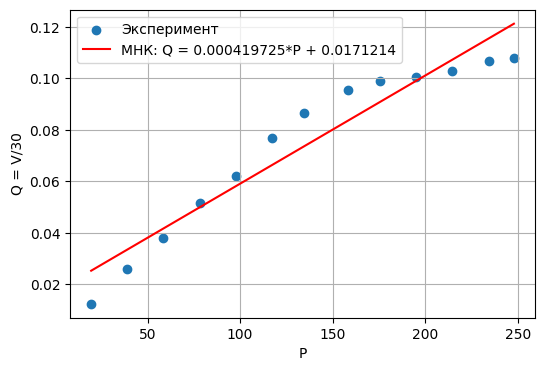

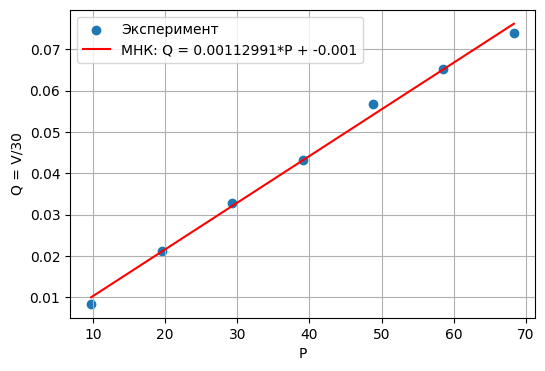

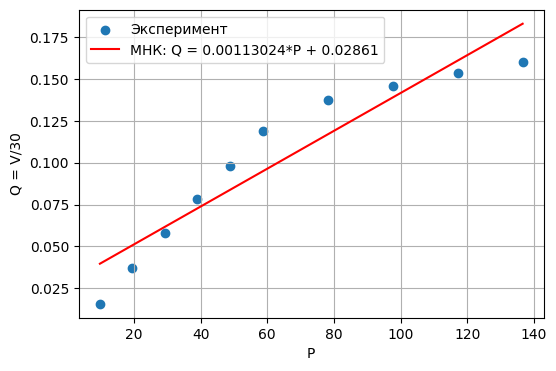

Коэффициенты МНК (Q = k*P + b):
d3(50): k = 0.000419725, b = 0.0171214
d2(30): k = 0.00112991, b = -0.001
d1(50): k = 0.00113024, b = 0.02861


In [22]:

mnk_results = {}

for name, df in tube_tables.items():
    work = df.copy()
    work["Q"] = work["V"] / 30.0

    P = work["P"].to_numpy(dtype=float)
    Q = work["Q"].to_numpy(dtype=float)

    if len(P) < 2:
        print(f"{name}: недостаточно точек для МНК (нужно >= 2).")
        continue

    k, b = np.polyfit(P, Q, 1)
    Q_fit = k * P + b

    mnk_results[name] = {"k": k, "b": b}

    plt.figure(figsize=(6, 4))
    plt.scatter(P, Q, label="Эксперимент")
    plt.plot(P, Q_fit, color="red", label=f"МНК: Q = {k:.6g}*P + {b:.6g}")
    plt.xlabel("P")
    plt.ylabel("Q = V/30")
    plt.grid(True)
    plt.legend()
    plt.show()

print("Коэффициенты МНК (Q = k*P + b):")
for name, res in mnk_results.items():
    print(f"{name}: k = {res['k']:.6g}, b = {res['b']:.6g}")

P(x)

d3

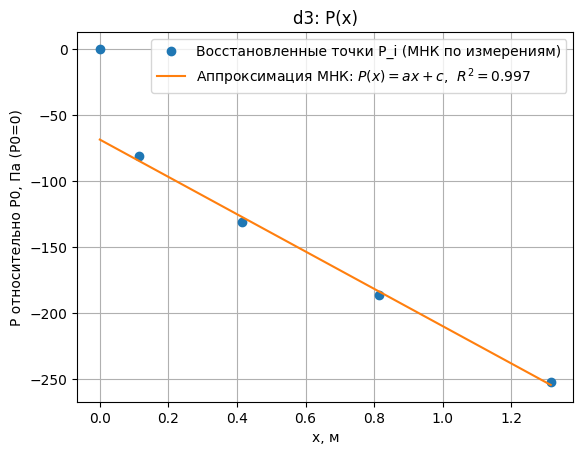

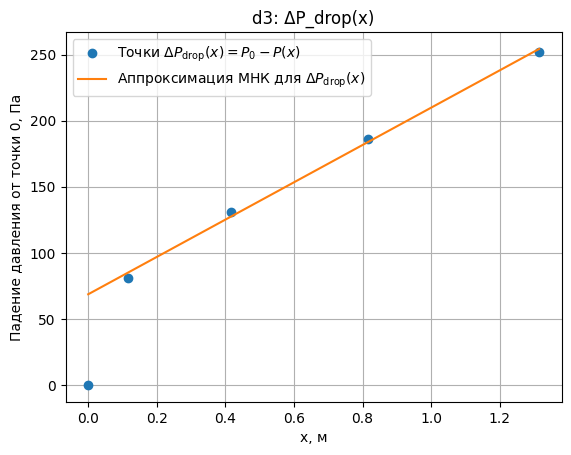

Точки и восстановленные давления (P0 = 0):
  0: x=0.000000 м,  P=0.000 Па
  1: x=0.115000 м,  P=-80.818 Па
  2: x=0.415000 м,  P=-131.183 Па
  3: x=0.815000 м,  P=-186.232 Па
  4: x=1.315000 м,  P=-251.824 Па

RMSE по уравнениям P_i - P_j = ΔP_ij: 1.053 Па
Линейная аппроксимация на точках 1..4: a=-141.203 Па/м, c=-68.614 Па, R^2=0.997


In [27]:

# 1.1) Заголовок графиков d3 (измени при необходимости)
PLOT_TITLE_D3 = "d3"
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) ВХОДНЫЕ ДАННЫЕ
# =========================

# Коэффициенты микроманометра
K = 0.2       # твой наклон
n_corr = 0.9953  # твоя поправка по температуре

# Координаты точек (в метрах). Если у тебя другие — замени.
x = np.array([0.000, 0.115, 0.415, 0.815, 1.315], dtype=float)

# Твои измерения N: считаем, что ΔP_ij = P_i - P_j = 9.8067 * N * K * n
measurements = [
    {"i": 0, "j": 1, "N": 42},
    {"i": 0, "j": 2, "N": 67},
    {"i": 0, "j": 3, "N": 95},
    {"i": 0, "j": 4, "N": 129},
    {"i": 1, "j": 2, "N": 27},
    {"i": 1, "j": 3, "N": 54},
    {"i": 1, "j": 4, "N": 87},
    {"i": 2, "j": 3, "N": 29},
    {"i": 2, "j": 4, "N": 62},
    {"i": 3, "j": 4, "N": 34},
]

# =========================
# 2) N -> ΔP (Па) и восстановление P_i по МНК
# =========================

G = 9.8067
n_points = len(x)

# Составляем систему A P = b из уравнений P_i - P_j = ΔP_ij
A = []
b = []
for m in measurements:
    i, j = int(m["i"]), int(m["j"])
    N = float(m["N"])
    dP = G * N * K * n_corr  # Па
    row = np.zeros(n_points)
    row[i] = 1.0
    row[j] = -1.0
    A.append(row)
    b.append(dP)

# Фиксируем уровень отсчёта: P0 = 0
row0 = np.zeros(n_points)
row0[0] = 1.0
A.append(row0)
b.append(0.0)

A = np.vstack(A)
b = np.array(b, dtype=float)

# Решение МНК
P, *_ = np.linalg.lstsq(A, b, rcond=None)

# Для удобства: падение давления от точки 0
P_drop = -P  # т.к. P0=0

# =========================
# 3) Аппроксимация P(x) методом МНК (гладкая линия)
# =========================

# ВЫБОР УЧАСТКА ДЛЯ АППРОКСИМАЦИИ:
# - если хочешь аппроксимацию по всем точкам: fit_from = 0
# - если хочешь исключить входной участок (обычно точка 0 или 0..1): fit_from = 1 или 2
fit_from = 1
xf = x[fit_from:]
Pf = P[fit_from:]

# Линейная аппроксимация: P(x) = a*x + c
a, c = np.polyfit(xf, Pf, deg=1)

# Гладкая линия
x_line = np.linspace(x.min(), x.max(), 300)
P_line = a * x_line + c

# (опционально) оценка качества аппроксимации на выбранном участке
P_pred = a * xf + c
ss_res = np.sum((Pf - P_pred) ** 2)
ss_tot = np.sum((Pf - np.mean(Pf)) ** 2)
R2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

# =========================
# 4) Графики
# =========================

plt.figure()
plt.plot(x, P, "o", label="Восстановленные точки P_i (МНК по измерениям)")
plt.plot(x_line, P_line, "-", label=fr"Аппроксимация МНК: $P(x)=ax+c$,  $R^2={R2:.3f}$")
plt.xlabel("x, м")
plt.ylabel("P относительно P0, Па (P0=0)")
plt.title(f"{PLOT_TITLE_D3}: P(x)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(x, P_drop, "o", label=r"Точки $\Delta P_{\mathrm{drop}}(x)=P_0-P(x)$")
plt.plot(x_line, -P_line, "-", label=r"Аппроксимация МНК для $\Delta P_{\mathrm{drop}}(x)$")
plt.xlabel("x, м")
plt.ylabel("Падение давления от точки 0, Па")
plt.title(f"{PLOT_TITLE_D3}: ΔP_drop(x)")
plt.grid(True)
plt.legend()
plt.show()

# =========================
# 5) Печать таблицы + диагностика согласованности измерений
# =========================

print("Точки и восстановленные давления (P0 = 0):")
for idx, (xi, Pi) in enumerate(zip(x, P)):
    print(f"  {idx}: x={xi:.6f} м,  P={Pi:.3f} Па")

# Среднеквадратичная невязка по уравнениям (насколько измерения между собой согласованы)
residuals = A @ P - b
rmse = np.sqrt(np.mean(residuals**2))
print(f"\nRMSE по уравнениям P_i - P_j = ΔP_ij: {rmse:.3f} Па")
print(f"Линейная аппроксимация на точках {fit_from}..{n_points-1}: a={a:.3f} Па/м, c={c:.3f} Па, R^2={R2:.3f}")


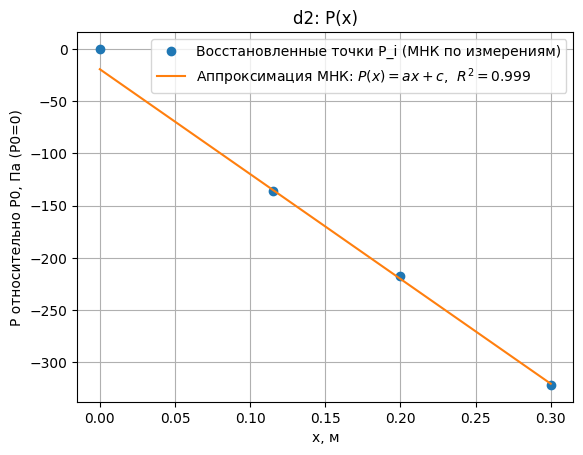

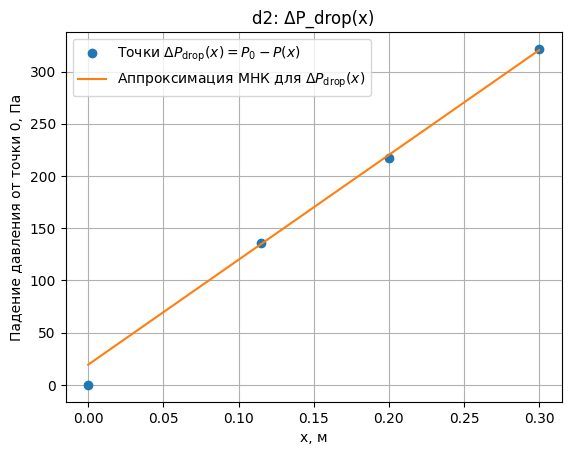

Точки и восстановленные давления (P0 = 0):
  0: x=0.000000 м,  P=0.000 Па
  1: x=0.115000 м,  P=-136.160 Па
  2: x=0.200000 м,  P=-217.662 Па
  3: x=0.300000 м,  P=-321.612 Па

RMSE по уравнениям P_i - P_j = ΔP_ij: 0.522 Па
Линейная аппроксимация на точках 1..3: a=-1003.521 Па/м, c=-19.423 Па, R^2=0.999


In [28]:

# 1.1) Заголовок графиков d2 (измени при необходимости)
PLOT_TITLE_D3 = "d2"
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) ВХОДНЫЕ ДАННЫЕ
# =========================

# Коэффициенты микроманометра
K = 0.2       # твой наклон
n_corr = 0.9953  # твоя поправка по температуре

# Координаты точек (в метрах). Если у тебя другие — замени.
x = np.array([0.000, 0.115, 0.200, 0.300], dtype=float)

# Твои измерения N: считаем, что ΔP_ij = P_i - P_j = 9.8067 * N * K * n
measurements = [
    {"i": 0, "j": 1, "N": 70},
    {"i": 0, "j": 2, "N": 111},
    {"i": 0, "j": 3, "N": 165},
    {"i": 1, "j": 2, "N": 42},
    {"i": 1, "j": 3, "N": 95},
    {"i": 2, "j": 3, "N": 53},
]

# =========================
# 2) N -> ΔP (Па) и восстановление P_i по МНК
# =========================

G = 9.8067
n_points = len(x)

# Составляем систему A P = b из уравнений P_i - P_j = ΔP_ij
A = []
b = []
for m in measurements:
    i, j = int(m["i"]), int(m["j"])
    N = float(m["N"])
    dP = G * N * K * n_corr  # Па
    row = np.zeros(n_points)
    row[i] = 1.0
    row[j] = -1.0
    A.append(row)
    b.append(dP)

# Фиксируем уровень отсчёта: P0 = 0
row0 = np.zeros(n_points)
row0[0] = 1.0
A.append(row0)
b.append(0.0)

A = np.vstack(A)
b = np.array(b, dtype=float)

# Решение МНК
P, *_ = np.linalg.lstsq(A, b, rcond=None)

# Для удобства: падение давления от точки 0
P_drop = -P  # т.к. P0=0

# =========================
# 3) Аппроксимация P(x) методом МНК (гладкая линия)
# =========================

# ВЫБОР УЧАСТКА ДЛЯ АППРОКСИМАЦИИ:
# - если хочешь аппроксимацию по всем точкам: fit_from = 0
# - если хочешь исключить входной участок (обычно точка 0 или 0..1): fit_from = 1 или 2
fit_from = 1
xf = x[fit_from:]
Pf = P[fit_from:]

# Линейная аппроксимация: P(x) = a*x + c
a, c = np.polyfit(xf, Pf, deg=1)

# Гладкая линия
x_line = np.linspace(x.min(), x.max(), 300)
P_line = a * x_line + c

# (опционально) оценка качества аппроксимации на выбранном участке
P_pred = a * xf + c
ss_res = np.sum((Pf - P_pred) ** 2)
ss_tot = np.sum((Pf - np.mean(Pf)) ** 2)
R2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

# =========================
# 4) Графики
# =========================

plt.figure()
plt.plot(x, P, "o", label="Восстановленные точки P_i (МНК по измерениям)")
plt.plot(x_line, P_line, "-", label=fr"Аппроксимация МНК: $P(x)=ax+c$,  $R^2={R2:.3f}$")
plt.xlabel("x, м")
plt.ylabel("P относительно P0, Па (P0=0)")
plt.title(f"{PLOT_TITLE_D3}: P(x)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(x, P_drop, "o", label=r"Точки $\Delta P_{\mathrm{drop}}(x)=P_0-P(x)$")
plt.plot(x_line, -P_line, "-", label=r"Аппроксимация МНК для $\Delta P_{\mathrm{drop}}(x)$")
plt.xlabel("x, м")
plt.ylabel("Падение давления от точки 0, Па")
plt.title(f"{PLOT_TITLE_D3}: ΔP_drop(x)")
plt.grid(True)
plt.legend()
plt.show()

# =========================
# 5) Печать таблицы + диагностика согласованности измерений
# =========================

print("Точки и восстановленные давления (P0 = 0):")
for idx, (xi, Pi) in enumerate(zip(x, P)):
    print(f"  {idx}: x={xi:.6f} м,  P={Pi:.3f} Па")

# Среднеквадратичная невязка по уравнениям (насколько измерения между собой согласованы)
residuals = A @ P - b
rmse = np.sqrt(np.mean(residuals**2))
print(f"\nRMSE по уравнениям P_i - P_j = ΔP_ij: {rmse:.3f} Па")
print(f"Линейная аппроксимация на точках {fit_from}..{n_points-1}: a={a:.3f} Па/м, c={c:.3f} Па, R^2={R2:.3f}")
